In [7]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
import warnings
warnings.simplefilter("ignore")

In [9]:
train_df= pd.read_csv(r"C:\Users\DELL\Desktop\MLOPS\artifacts\raw\train.csv")
train_df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN28387,1,0,1,4,Meal Plan 1,0,Room_Type 1,209,2017,7,29,Online,0,0,0,55.96,0,Canceled
1,INN06538,2,0,0,4,Meal Plan 1,0,Room_Type 1,104,2018,7,6,Online,0,0,0,83.12,1,Not_Canceled
2,INN16940,2,1,2,2,Meal Plan 1,0,Room_Type 1,42,2018,8,14,Online,0,0,0,152.10,1,Not_Canceled
3,INN22121,2,1,0,4,Meal Plan 1,0,Room_Type 1,201,2018,11,1,Online,0,0,0,82.28,3,Not_Canceled
4,INN21298,3,0,1,4,Meal Plan 1,0,Room_Type 4,79,2018,7,11,Online,0,0,0,139.50,0,Not_Canceled


In [10]:
train_df.dtypes

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

In [11]:
train_df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [12]:
train_df.drop(columns=["Booking_ID"],inplace=True)

In [13]:
train_df.shape

(29020, 18)

In [14]:
train_df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [15]:
train_df.duplicated().sum()

np.int64(7669)

In [16]:
train_df.drop_duplicates(inplace=True)

In [17]:
train_df.shape

(21351, 18)

In [18]:
train_df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [19]:
train_df["no_of_weekend_nights"].value_counts()

no_of_weekend_nights
0    9096
1    6094
2    5909
3     110
4     101
5      21
6      19
7       1
Name: count, dtype: int64

#Our data is imbalanced

In [20]:
cat_col=train_df.select_dtypes(include=["category","object"])

In [21]:
num_col=train_df.select_dtypes(include=["number"])

In [22]:
cat_col

,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
0,Meal Plan 1,Room_Type 1,Online,Canceled
1,Meal Plan 1,Room_Type 1,Online,Not_Canceled
2,Meal Plan 1,Room_Type 1,Online,Not_Canceled
3,Meal Plan 1,Room_Type 1,Online,Not_Canceled
4,Meal Plan 1,Room_Type 4,Online,Not_Canceled
...,...,...,...,...
29011,Meal Plan 1,Room_Type 1,Offline,Not_Canceled
29013,Meal Plan 1,Room_Type 4,Online,Canceled
29014,Meal Plan 1,Room_Type 1,Online,Not_Canceled
29015,Meal Plan 1,Room_Type 1,Offline,Not_Canceled


In [23]:
num_col

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,1,0,1,4,0,209,2017,7,29,0,0,0,55.96,0
1,2,0,0,4,0,104,2018,7,6,0,0,0,83.12,1
2,2,1,2,2,0,42,2018,8,14,0,0,0,152.10,1
3,2,1,0,4,0,201,2018,11,1,0,0,0,82.28,3
4,3,0,1,4,0,79,2018,7,11,0,0,0,139.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29011,2,0,2,1,0,17,2018,5,21,0,0,0,95.00,0
29013,2,0,1,3,0,103,2018,5,5,0,0,0,124.53,0
29014,1,0,0,1,0,46,2018,7,8,0,0,0,112.50,2
29015,1,0,0,2,0,79,2018,6,24,0,0,0,95.00,0


#Data Analysis

In [24]:
data=train_df.copy()

In [25]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,1,0,1,4,Meal Plan 1,0,Room_Type 1,209,2017,7,29,Online,0,0,0,55.96,0,Canceled
1,2,0,0,4,Meal Plan 1,0,Room_Type 1,104,2018,7,6,Online,0,0,0,83.12,1,Not_Canceled
2,2,1,2,2,Meal Plan 1,0,Room_Type 1,42,2018,8,14,Online,0,0,0,152.10,1,Not_Canceled
3,2,1,0,4,Meal Plan 1,0,Room_Type 1,201,2018,11,1,Online,0,0,0,82.28,3,Not_Canceled
4,3,0,1,4,Meal Plan 1,0,Room_Type 4,79,2018,7,11,Online,0,0,0,139.50,0,Not_Canceled


UNIVARIATE ANALYSIS

NameError: name 'df' is not defined

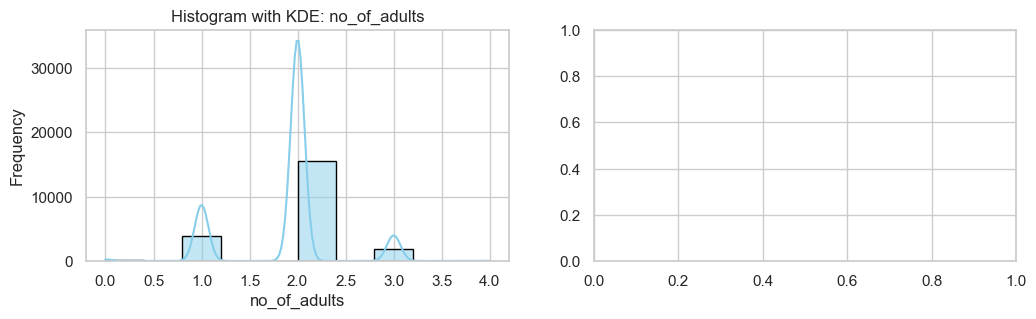

In [ ]:
sns.set(style="whitegrid")

 
for col in num_col.columns:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 3))
    
    # Histogram + KDE
    sns.histplot(data[col], kde=True, bins=10, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Histogram with KDE: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # Box Plot
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Box Plot: {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

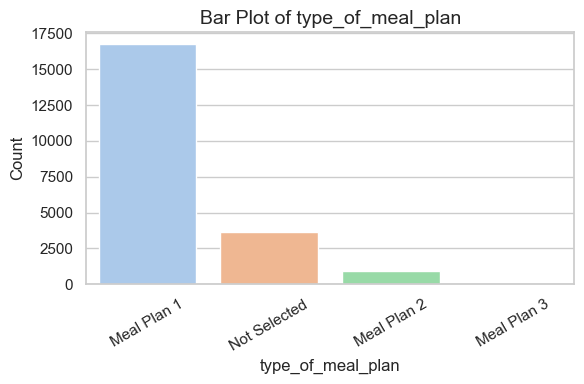

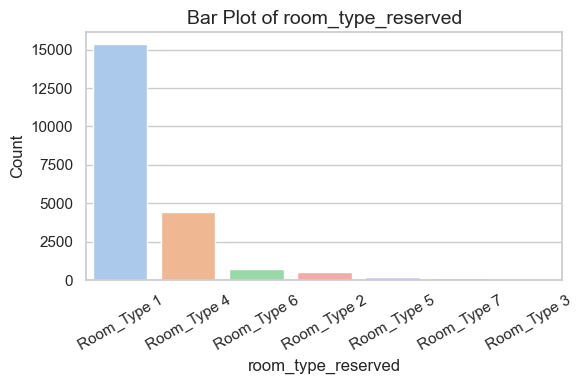

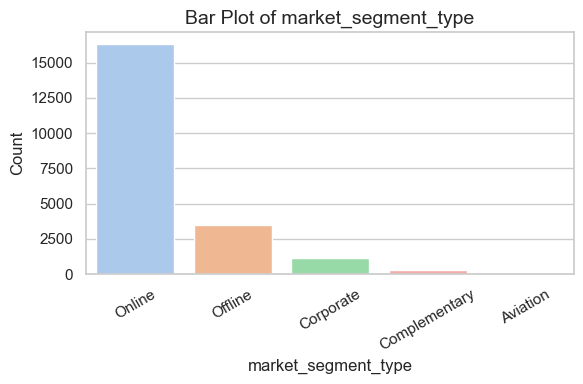

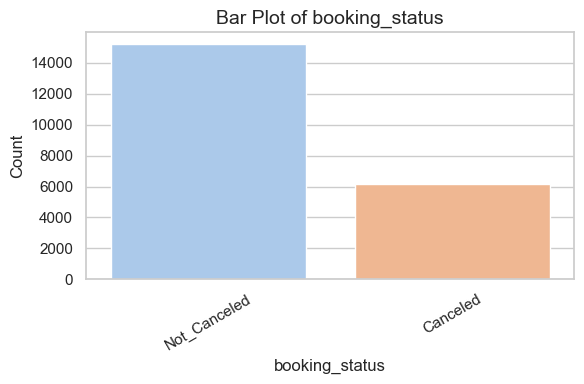

In [ ]:
sns.set(style="whitegrid")

# Plot bar charts for each categorical column
for col in cat_col.columns:
    plt.figure(figsize=(6, 4))
    value_counts = data[col].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')
    plt.title(f'Bar Plot of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
#data Preprocessing 

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21351 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21351 non-null  int64  
 1   no_of_children                        21351 non-null  int64  
 2   no_of_weekend_nights                  21351 non-null  int64  
 3   no_of_week_nights                     21351 non-null  int64  
 4   type_of_meal_plan                     21351 non-null  object 
 5   required_car_parking_space            21351 non-null  int64  
 6   room_type_reserved                    21351 non-null  object 
 7   lead_time                             21351 non-null  int64  
 8   arrival_year                          21351 non-null  int64  
 9   arrival_month                         21351 non-null  int64  
 10  arrival_date                          21351 non-null  int64  
 11  market_segment_type 

In [37]:
#Lable encoding

from sklearn.preprocessing import LabelEncoder

In [38]:
labelEncoder=LabelEncoder()

mapping={}
for col in cat_col:
    data[col]=labelEncoder.fit_transform(data[col])

    mapping[col]={label:Code for label,Code in zip(labelEncoder.classes_ ,labelEncoder.transform(labelEncoder.classes_))}


In [39]:
data.dtypes

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                         int64
required_car_parking_space                int64
room_type_reserved                        int64
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                       int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                            int64
dtype: object

In [ ]:
#Multicolinearity

In [ ]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 8.4 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.6 MB 7.2 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.6 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.1 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
  

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [ ]:
x=add_constant(data)

vif_data=pd.DataFrame()

vif_data["feature"] =x.columns
vif_data["vif"]=[variance_inflation_factor(x.values,i) for i in range (x.shape[1])]

In [ ]:
vif_data

,feature,vif
0,const,4.012442e+07
1,no_of_adults,1.275303e+00
2,no_of_children,1.284910e+00
3,no_of_weekend_nights,1.078393e+00
4,no_of_week_nights,1.123840e+00
5,type_of_meal_plan,1.047321e+00
6,required_car_parking_space,1.030311e+00
7,room_type_reserved,1.261000e+00
8,lead_time,1.378913e+00
9,arrival_year,1.264578e+00


In [ ]:
#there is no multicollinearity in our data

In [ ]:
corr=data.corr()

In [ ]:
corr

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
no_of_adults,1.000000,-0.048337,0.089647,0.112174,-0.000881,0.002118,0.119996,0.150874,0.094211,0.007735,0.018976,-0.305325,-0.231974,-0.060436,-0.140024,0.320874,0.159747,-0.091734
no_of_children,-0.048337,1.000000,0.011587,0.010988,-0.054633,0.016330,0.353342,0.003906,0.029248,0.004519,0.023233,-0.095516,-0.048128,-0.020279,-0.028374,0.341184,0.093543,-0.059554
no_of_weekend_nights,0.089647,0.011587,1.000000,0.238834,-0.016953,-0.048377,0.013847,0.136447,0.028382,0.014921,0.005058,-0.087163,-0.085990,-0.025109,-0.032360,-0.003587,0.015091,-0.070432
no_of_week_nights,0.112174,0.010988,0.238834,1.000000,-0.045112,-0.056817,0.052304,0.218519,0.020054,0.027170,-0.009642,-0.112538,-0.113460,-0.032626,-0.052948,0.014043,0.030783,-0.127341
type_of_meal_plan,-0.000881,-0.054633,-0.016953,-0.045112,1.000000,-0.018538,-0.151695,0.035650,0.042882,0.020604,0.006489,-0.100069,-0.069765,-0.019438,-0.045313,0.017526,-0.029367,-0.052037
required_car_parking_space,0.002118,0.016330,-0.048377,-0.056817,-0.018538,1.000000,0.012938,-0.039055,0.003805,-0.016737,-0.005763,0.028938,0.099913,0.022428,0.047402,0.057729,0.070295,0.084860
room_type_reserved,0.119996,0.353342,0.013847,0.052304,-0.151695,0.012938,1.000000,0.011400,0.050061,0.001115,0.026576,-0.022085,-0.021121,-0.004856,-0.003128,0.318425,0.049003,-0.044737
lead_time,0.150874,0.003906,0.136447,0.218519,0.035650,-0.039055,0.011400,1.000000,0.173529,0.129294,0.036759,-0.136579,-0.147347,-0.053534,-0.085239,-0.046176,-0.017364,-0.371255
arrival_year,0.094211,0.029248,0.028382,0.020054,0.042882,0.003805,0.050061,0.173529,1.000000,-0.324634,0.019231,-0.113386,-0.014653,0.009492,0.023106,0.174263,0.001419,-0.153427
arrival_month,0.007735,0.004519,0.014921,0.027170,0.020604,-0.016737,0.001115,0.129294,-0.324634,1.000000,-0.026133,0.019520,0.005349,-0.043337,-0.003042,0.068175,0.128714,0.011428


<Axes: >

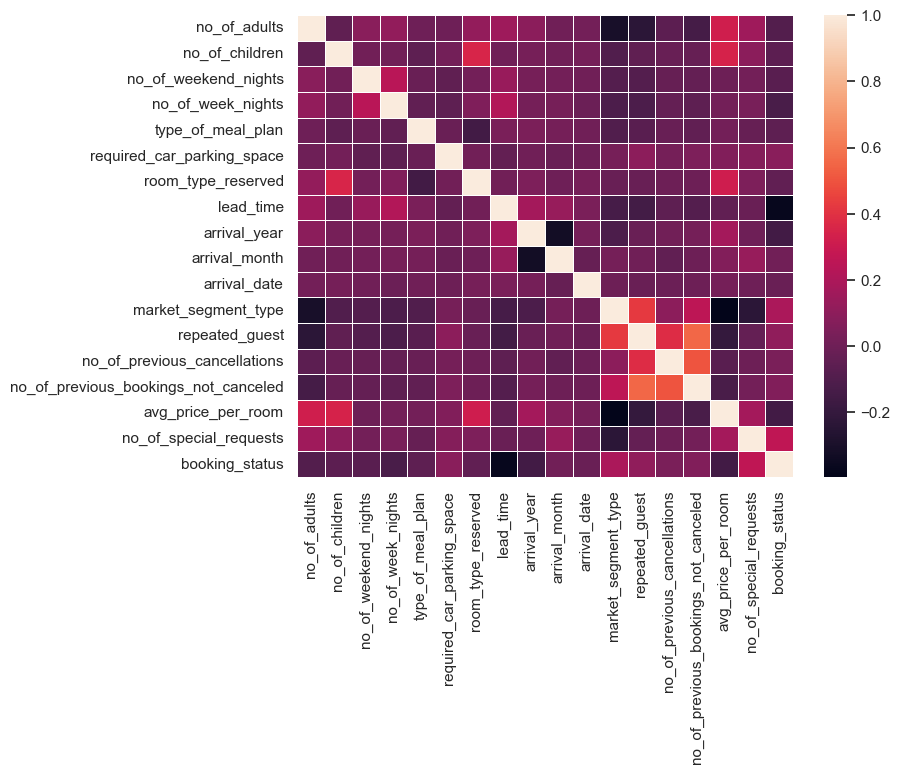

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,linewidths=0.6)

In [ ]:
# Skewness

In [ ]:
skewness= data.skew()

In [ ]:
skewness

no_of_adults                            -0.285505
no_of_children                           4.247117
no_of_weekend_nights                     0.682935
no_of_week_nights                        1.655122
type_of_meal_plan                        1.941026
required_car_parking_space               4.601265
room_type_reserved                       2.833172
lead_time                                1.406488
arrival_year                            -1.947553
arrival_month                           -0.292399
arrival_date                             0.011045
market_segment_type                      2.373386
repeated_guest                           5.371794
no_of_previous_cancellations            22.586761
no_of_previous_bookings_not_canceled    16.583476
avg_price_per_room                       0.633609
no_of_special_requests                   0.931220
booking_status                          -0.938943
dtype: float64

In [ ]:
for col in data.columns:
    if skewness[col] >5:
        data[col]=np.log1p(data[col])


In [ ]:
skewness= data.skew()

In [ ]:
skewness

no_of_adults                            -0.285505
no_of_children                           4.247117
no_of_weekend_nights                     0.682935
no_of_week_nights                        1.655122
type_of_meal_plan                        1.941026
required_car_parking_space               4.601265
room_type_reserved                       2.833172
lead_time                                1.406488
arrival_year                            -1.947553
arrival_month                           -0.292399
arrival_date                             0.011045
market_segment_type                      2.373386
repeated_guest                           5.371794
no_of_previous_cancellations            13.506147
no_of_previous_bookings_not_canceled     7.791714
avg_price_per_room                       0.633609
no_of_special_requests                   0.931220
booking_status                          -0.938943
dtype: float64

In [27]:
#feature selection

In [40]:
len(data.columns)

18

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
x= data.drop(columns=['booking_status'])
y=data['booking_status']

In [43]:
model=RandomForestClassifier(random_state=34)
model.fit(x,y)

RandomForestClassifier(random_state=34)

In [75]:
feature_importance=model.feature_importances_

In [76]:
feature_importance__df=pd.DataFrame(
    {
        "feture":x.columns,
        "importance":feature_importance
    }
)

In [77]:
feature_importance__df

,feture,importance
0,no_of_adults,0.019283
1,no_of_children,0.009227
2,no_of_weekend_nights,0.037206
3,no_of_week_nights,0.056928
4,type_of_meal_plan,0.016535
5,required_car_parking_space,0.009267
6,room_type_reserved,0.018850
7,lead_time,0.286080
8,arrival_year,0.019771
9,arrival_month,0.080821


In [78]:
top_fetures_df=feature_importance__df.sort_values(by="importance",ascending=False)

In [90]:
top_fetures_df

,feture,importance
7,lead_time,0.286080
15,avg_price_per_room,0.161480
16,no_of_special_requests,0.123895
10,arrival_date,0.096680
9,arrival_month,0.080821
11,market_segment_type,0.059797
3,no_of_week_nights,0.056928
2,no_of_weekend_nights,0.037206
8,arrival_year,0.019771
0,no_of_adults,0.019283


In [79]:
top_ten_fetures=top_fetures_df["feture"].head(10).values
 

In [80]:
top_ten_fetures_df=data[top_ten_fetures.tolist() + ["booking_status"]]

In [ ]:
top_ten_fetures_df.head()

,lead_time,avg_price_per_room,no_of_special_requests,arrival_date,arrival_month,market_segment_type,no_of_week_nights,no_of_weekend_nights,arrival_year,no_of_adults,booking_status
0,209,55.96,0,29,7,4,4,1,2017,1,0
1,104,83.12,1,6,7,4,4,0,2018,2,1
2,42,152.10,1,14,8,4,2,2,2018,2,1
3,201,82.28,3,1,11,4,4,0,2018,2,1
4,79,139.50,0,11,7,4,4,1,2018,3,1


In [83]:
len(top_ten_fetures_df.columns)

11

In [84]:
df=top_ten_fetures_df.copy()

In [87]:
df

,lead_time,avg_price_per_room,no_of_special_requests,arrival_date,arrival_month,market_segment_type,no_of_week_nights,no_of_weekend_nights,arrival_year,no_of_adults,booking_status
0,209,55.96,0,29,7,4,4,1,2017,1,0
1,104,83.12,1,6,7,4,4,0,2018,2,1
2,42,152.10,1,14,8,4,2,2,2018,2,1
3,201,82.28,3,1,11,4,4,0,2018,2,1
4,79,139.50,0,11,7,4,4,1,2018,3,1
...,...,...,...,...,...,...,...,...,...,...,...
29011,17,95.00,0,21,5,3,1,2,2018,2,1
29013,103,124.53,0,5,5,4,3,1,2018,2,0
29014,46,112.50,2,8,7,4,1,0,2018,1,1
29015,79,95.00,0,24,6,3,2,0,2018,1,1


In [88]:
# model selecction 

In [89]:
!pip install xgboost lightgbm

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 5.6 MB/s eta 0:00:27
   - -------------------------------------- 4.2/150.0 MB 14.8 MB/s eta 0:00:10
   - -------------------------------------- 6.8/150.0 MB 13.5 MB/s eta 0:00:11
   -- ------------------------------------- 10.2/150.0 MB 14.2 MB/s eta 0:00:10
   ---- ----------------------------------- 17.8/150.0 MB 18.7 MB/s eta 0:00:08
   ----- ---------------------------------- 22.3/150.0 MB 19.0 MB/s eta 0:00:07
   ------ --------------------------------- 23.1/150.0 MB 19.5 MB/s eta 0:00:07
   ------ --------------------------------- 26.0/150.0 MB 16.4 MB/s eta 0:00:08
   ------- -------------------------------- 28.0/150.0 MB 15.5 MB/s eta 0:00:08
   -------- ------------------------------- 30.7/150.0 MB 15.2 MB/s eta 0:00:08
   -------- ------------------------------- 32.8/150.0 MB 14.8 MB/s eta 0:00:08
   --------- ------------------------------ 35.1/150.

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import  DecisionTreeClassifier
from sklearn.naive_bayes import  GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [93]:
x= df.drop(columns=['booking_status'])
y=df['booking_status']

In [116]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=23)

In [117]:
classifier={
    "RandomForestClassifier" :RandomForestClassifier(random_state=23),
    "LogisticRegression": LogisticRegression(random_state=23),
    "GradientBoostingClassifier":GradientBoostingClassifier(random_state=23),
    "svm":SVC(random_state=23),
    "DecisionTreeClassifier":DecisionTreeClassifier(random_state=23),
    "KNeighborsClassifier":KNeighborsClassifier(),
    "XGBClassifier":XGBClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier(random_state=23),
    "LGBMClassifier":LGBMClassifier(random_state=23),
    "GaussianNB": GaussianNB()

}

In [118]:
metrics={
    "models":[],
    "accuracy":[],
    "precision":[],
    "Recall":[],
    "f1_score":[]
}

In [119]:
for model_name,classifier in classifier.items():
    classifier.fit(x_train,y_train)

    y_pred= classifier.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    
    metrics["models"].append(model_name)
    metrics["accuracy"].append(accuracy)
    metrics["precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["f1_score"].append(f1)




In [120]:
metrics_df=pd.DataFrame(metrics)

In [121]:
metrics_df

,models,accuracy,precision,Recall,f1_score
0,RandomForestClassifier,0.853664,0.878722,0.923704,0.900652
1,LogisticRegression,0.800983,0.826895,0.914248,0.868380
2,GradientBoostingClassifier,0.849216,0.874266,0.922726,0.897843
3,svm,0.755795,0.758427,0.968373,0.850637
4,DecisionTreeClassifier,0.800749,0.868106,0.851973,0.859964
5,KNeighborsClassifier,0.752049,0.795642,0.880991,0.836144
6,XGBClassifier,0.851557,0.879563,0.919139,0.898916
7,AdaBoostClassifier,0.805432,0.822562,0.929573,0.872800
8,LGBMClassifier,0.860688,0.886492,0.924356,0.905028
9,GaussianNB,0.771248,0.858860,0.815455,0.836595
